In [6]:
import pandas as pd
import geopandas as gpd
import openpyxl 

import matplotlib.pyplot as plt
import seaborn as sns

import requests 
import time

from tqdm.auto import tqdm


In [7]:
!gdown --format xlsx "https://docs.google.com/spreadsheets/d/1dmxPcdc1VN6Pixpui3FIFgYUyC7h2DSQ/edit?usp=sharing" -O reestr.xlsx

Downloading...
From (original): https://drive.google.com/uc?id=1dmxPcdc1VN6Pixpui3FIFgYUyC7h2DSQ
From (redirected): https://drive.google.com/uc?id=1dmxPcdc1VN6Pixpui3FIFgYUyC7h2DSQ&confirm=t&uuid=d4f9f2af-6cc9-4738-b7df-000212aa37c1
To: C:\Users\Honor\PycharmProjects\Something file\reestr.xlsx

  0%|          | 0.00/89.0M [00:00<?, ?B/s]
  2%|1         | 1.57M/89.0M [00:00<00:14, 5.95MB/s]
  3%|2         | 2.62M/89.0M [00:00<00:15, 5.45MB/s]
  5%|5         | 4.72M/89.0M [00:00<00:09, 8.57MB/s]
  6%|6         | 5.77M/89.0M [00:00<00:09, 8.98MB/s]
  8%|7         | 6.82M/89.0M [00:00<00:08, 9.29MB/s]
  9%|9         | 8.39M/89.0M [00:00<00:08, 9.87MB/s]
 11%|#1        | 9.96M/89.0M [00:01<00:07, 10.2MB/s]
 13%|#2        | 11.5M/89.0M [00:01<00:07, 10.6MB/s]
 15%|#4        | 13.1M/89.0M [00:01<00:06, 11.0MB/s]
 16%|#6        | 14.7M/89.0M [00:01<00:06, 11.2MB/s]
 18%|#8        | 16.3M/89.0M [00:01<00:07, 10.1MB/s]
 20%|##        | 17.8M/89.0M [00:01<00:06, 11.1MB/s]
 22%|##1       | 19.4M/8

In [8]:
df = pd.read_excel("reestr.xlsx", header=2)

C:\Users\Honor\PycharmProjects\Something file\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [9]:
df.head(3)

,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационной, высокотехнологичной продукции",Участие в программах партнерства,Является социальным предприятием,Среднесписочная численность работников за предшествующий календарный год
0,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
1,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [10]:
df["Категория"].value_counts()

Категория
Не является субъектом МСП    348477
Микропредприятие             243832
Малое предприятие             10310
Среднее предприятие             901
Name: count, dtype: int64

In [11]:
df["Основной вид деятельности"].value_counts()

Основной вид деятельности
41.20 Строительство жилых и нежилых зданий    530132
41.2 Строительство жилых и нежилых зданий      45559
41.10 Разработка строительных проектов         27698
41 Строительство зданий                          130
41.1 Разработка строительных проектов              1
Name: count, dtype: int64

In [12]:
mask_category = (df["Категория"] == "Малое предприятие") | (df["Категория"] == "Среднее предприятие")
mask_sybject = df["Тип субъекта"] == "Юридическое лицо"
mask_type = df["Основной вид деятельности"] == "41.20 Строительство жилых и нежилых зданий"

mask_result = mask_category & mask_sybject & mask_type

In [13]:
df_result = df[mask_result]["ИНН"]

In [14]:
df_result.shape

(8927,)

In [15]:
list_result = df_result.to_list()
test_inns = list_result[:300]

In [16]:
list_result[0]

5038038838

In [17]:
# all_rows = []
# import random

# session = requests.Session()
# for inn in tqdm(list_result):
#     try:
#         url_for_id = f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}"
#         headers_id = {
#             "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
#             "Accept": "application/json, text/plain, */*",
#             "Referer": "https://bo.nalog.gov.ru/advanced-search"
#         }
#         response_id = session.get(url_for_id, headers=headers_id, timeout=15)

#         if response_id.status_code == 429:
#             print(f"\nID: TOO MANY REQUESTS на ИНН {inn}.")
#             break

    
#         if response_id.status_code != 200:
#             print(f"Ошибка поиска {inn}: {response_id.status_code}")
#             time.sleep(random.uniform(0.1, 0.3))
#             continue
        
#         data_id = response_id.json()
#         if not data_id.get("content"):
#             print(f"ИНН {inn} не найден")
#             time.sleep(random.uniform(0.1, 0.3))
#             continue
#         id_org = data_id["content"][0]["id"]


#         url_BFO = f"https://bo.nalog.gov.ru/nbo/organizations/{id_org}/bfo/"
#         headers_BFO = {"User-Agent": "Mozilla/5.0"}
#         resp_BFO = session.get(url_BFO, headers=headers_BFO, timeout=15)
        
#         if resp_BFO.status_code == 429:
#             print(f"\nBFO: TOO MANY REQUESTS на ИНН {inn}.")
#             break
#         if resp_BFO.status_code != 200:
#             print(f"Ошибка при загрузке BFO для {inn}, статус {resp_BFO.status_code}")
#             time.sleep(random.uniform(0.1, 0.3))
#             continue
            
#         data_BFO = resp_BFO.json()

#         for report in data_BFO:
#             period = report.get("period")
#             correction = report.get("typeCorrections", [{}])[0].get("correction", {})

#             fin = correction.get("financialResult", {})
#             balance = correction.get("balance", {})

#             val2110 = fin.get("current2110")
#             val2120 = fin.get("current2120")
#             val2100 = fin.get("current2100")
#             val2220 = fin.get("current2220")
#             val2200 = fin.get("current2200")
#             val2400 = fin.get("current2400")
#             val2330 = fin.get("current2330")
#             val2410 = fin.get("current2410")

#             val1200 = balance.get("current1200")
#             val1300 = balance.get("current1300")
#             val1400 = balance.get("current1400")
#             val1500 = balance.get("current1500")

#             row = {
#                 "ИНН": inn,
#                 "Год": period,
#                 "Выручка": val2110,
#                 "Себестоимость": val2120,
#                 "Валовая прибыль": val2100,
#                 "Управленческие расходы": val2220,
#                 "Прибыль от продаж": val2200,
#                 "Проценты к уплате": val2330,
#                 "Чистая прибыль": val2400,
#                 "Оборотные активы": val1200,
#                 "Капитал и резервы": val1300,
#                 "Долгосрочные обязательства": val1400,
#                 "Краткосрочные обязательства": val1500,
#                 "Налог на прибыль": val2410
#             }
#             all_rows.append(row)
#         time.sleep(random.uniform(0.1, 0.3))
#     except Exception as e:
#         print(f"Ошибка для ИНН {inn}: {e}")
#         time.sleep(random.uniform(0.1, 0.3))
#         continue

# df_inn = pd.DataFrame(all_rows)
# df_inn.head()

In [18]:
#df_inn.tail()

In [19]:
#df_inn.to_csv("financial_data_full.csv", index=False, encoding="utf-8-sig")

In [137]:
!gdown  "https://drive.google.com/file/d/1VVQ-V884TJA6IjmBKbc71zWBQRZ5Q3Av/view?usp=sharing" -O financial_data_fulls.csv
df_inn_data =pd.read_csv("financial_data_fulls.csv")

Downloading...
From: https://drive.google.com/uc?id=1VVQ-V884TJA6IjmBKbc71zWBQRZ5Q3Av
To: C:\Users\Honor\PycharmProjects\Something file\financial_data_fulls.csv

  0%|          | 0.00/3.48M [00:00<?, ?B/s]
 15%|#5        | 524k/3.48M [00:00<00:01, 2.10MB/s]
 45%|####5     | 1.57M/3.48M [00:00<00:00, 3.57MB/s]
 75%|#######5  | 2.62M/3.48M [00:00<00:00, 4.70MB/s]
100%|##########| 3.48M/3.48M [00:00<00:00, 5.06MB/s]


In [138]:
df_inn_data.shape

(40323, 14)

In [139]:
df_inn_data.head(10)

,ИНН,Год,Выручка,Себестоимость,Валовая прибыль,Управленческие расходы,Прибыль от продаж,Проценты к уплате,Чистая прибыль,Оборотные активы,Капитал и резервы,Долгосрочные обязательства,Краткосрочные обязательства,Налог на прибыль
0,5038038838,2025,140064.0,103274.0,36790.0,36435.0,355.0,11869.0,-520.0,313708.0,630589.0,3710.0,258798.0,-63.0
1,5038038838,2024,112540.0,95619.0,16921.0,25710.0,-8789.0,1521.0,-20129.0,420322.0,611107.0,NaN,157656.0,-191.0
2,5038038838,2023,108966.0,90500.0,18466.0,25408.0,-8093.0,3334.0,-20913.0,469298.0,606621.0,NaN,198290.0,-248.0
3,5038038838,2022,118633.0,83747.0,34886.0,28364.0,2396.0,141.0,19518.0,487345.0,627535.0,0.0,258088.0,-336.0
4,5038038838,2021,184044.0,150023.0,34021.0,37142.0,-5813.0,5601.0,3080.0,532675.0,608017.0,0.0,351596.0,-320.0
5,5027006369,2025,1287757.0,513273.0,774484.0,NaN,774484.0,324.0,704973.0,1744407.0,2256685.0,3895.0,1153019.0,-48275.0
6,5027006369,2024,429496.0,419348.0,10148.0,NaN,10148.0,705.0,28998.0,666908.0,1551711.0,6478.0,2230502.0,-8184.0
7,5027006369,2023,1565001.0,854018.0,710983.0,NaN,710983.0,1946.0,582441.0,1020054.0,1537914.0,11832.0,2021846.0,-145629.0
8,5027006369,2022,683396.0,659189.0,24207.0,NaN,24207.0,2791.0,31442.0,1391395.0,1044808.0,33775.0,3353320.0,-8568.0
9,5027006369,2021,584219.0,554203.0,30016.0,NaN,30016.0,NaN,20376.0,1721593.0,1002906.0,NaN,4262404.0,-5463.0


In [140]:
df_inn_data["Год"].value_counts()

Год
2022    8713
2021    8403
2023    8239
2024    7722
2025    7246
Name: count, dtype: int64

In [141]:
df_trends_revenue_profit  = df_inn_data[
    ["ИНН", "Год", "Выручка", "Чистая прибыль"]
].copy()

In [142]:
df_trends_revenue_profit.head()


,ИНН,Год,Выручка,Чистая прибыль
0,5038038838,2025,140064.0,-520.0
1,5038038838,2024,112540.0,-20129.0
2,5038038838,2023,108966.0,-20913.0
3,5038038838,2022,118633.0,19518.0
4,5038038838,2021,184044.0,3080.0


In [143]:
df_trends_revenue_profit = df_trends_revenue_profit.dropna(
    subset=["Год", "Выручка", "Чистая прибыль"]
)


In [144]:
df_trends_revenue_profit.shape

(38882, 4)

In [145]:
df_trends_revenue_profit["Год"].value_counts()

Год
2022    8532
2021    8306
2023    7950
2024    7358
2025    6736
Name: count, dtype: int64

In [146]:
valid_inns = (
    df_trends_revenue_profit.groupby("ИНН")["Год"]
        .nunique()
)

In [147]:
valid_inns = valid_inns[valid_inns == 5].index

In [148]:
df_trends_revenue_profit_clear = df_trends_revenue_profit[df_trends_revenue_profit["ИНН"].isin(valid_inns)].copy()

In [149]:
df_trends_revenue_profit_clear.shape

(31930, 4)

In [150]:
print(
    df_trends_revenue_profit_clear.groupby("Год")["ИНН"].nunique()
)

Год
2021    6386
2022    6386
2023    6386
2024    6386
2025    6386
Name: ИНН, dtype: int64


In [151]:

def plot_revenue_profit_trend(df):
    import numpy as np

    industry = (
        df.groupby("Год", as_index=False)
          .agg({
              "Выручка": "sum",
              "Чистая прибыль": "sum"
          })
          .sort_values("Год")
    )
    
    industry["Выручка, млрд руб."] = (
        industry["Выручка"] / 1_000_000
    )
    
    industry["Чистая прибыль, млрд руб."] = (
        industry["Чистая прибыль"] / 1_000_000
    )

    
    x = np.arange(len(industry))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.bar(
        x - width / 2,
        industry["Выручка, млрд руб."],
        width,
        label="Выручка",
        color="orange"
    )

    ax1.bar(
        x + width / 2,
        industry["Чистая прибыль, млрд руб."],
        width,
        label="Чистая прибыль",
        color="green"
    )

    ax1.set_xlabel("Год")
    ax1.set_ylabel("млрд руб.")

    ax1.set_xticks(x)
    ax1.set_xticklabels(
        industry["Год"].astype(int)
    )

    ax1.legend(loc="upper left")
    ax1.grid(axis="y", alpha=0.3)


    plt.title(
    "Динамика выручки и чистой прибыли отрасли от 6386 компаний"
    )

    plt.tight_layout()
    plt.show()

    return industry

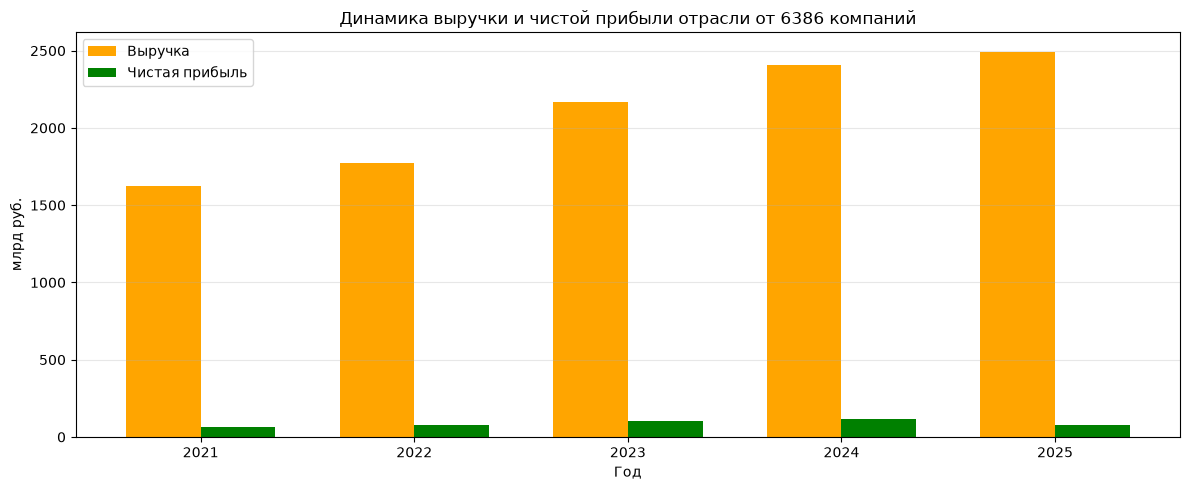

In [152]:
industry_revenue_profit = plot_revenue_profit_trend(
    df_trends_revenue_profit_clear
)

In [153]:
def plot_growth(df):
    
    yearly = df.groupby("Год", as_index=False)[["Выручка", "Чистая прибыль"]].sum()
    yearly = yearly.sort_values("Год")
    
    yearly["Рост выручки, %"] = yearly["Выручка"].pct_change() * 100
    yearly["Рост прибыли, %"] = yearly["Чистая прибыль"].pct_change() * 100
    
    plt.figure(figsize=(10, 5))
    plt.plot(yearly["Год"], yearly["Рост выручки, %"], marker='o', label="Рост выручки", color="orange")
    plt.plot(yearly["Год"], yearly["Рост прибыли, %"], marker='s', label="Рост чистой прибыли",color="green")
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel("Год")
    plt.ylabel("Прирост, %")
    plt.title("Годовой прирост выручки и чистой прибыли от 6386 компаний")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

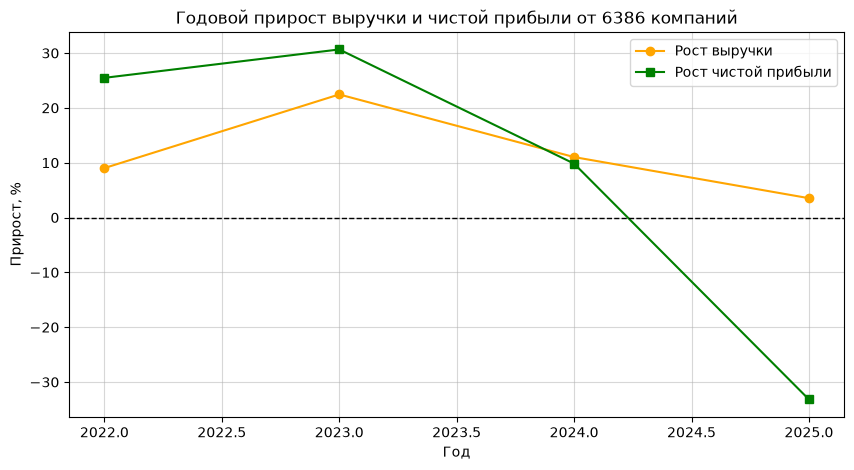

In [154]:
plot_growth(df_trends_revenue_profit_clear) 

In [155]:
# строительная отрасль в целом развивается в метрике выручки, однако прибыль, начиная с 2023 года, снижается от года к году минимум на 10%
# полную картину помогут отобразить другие графики

In [156]:
df_operating_profit = df_inn_data[
    ["ИНН", "Год", "Прибыль от продаж"]
].copy()

In [157]:
df_operating_profit = df_operating_profit.dropna(subset=["Год", "Прибыль от продаж"])

In [158]:
valid_inns = (
    df_operating_profit
    .groupby("ИНН")["Год"]
    .nunique()
)
valid_inns = valid_inns[valid_inns == 5].index

In [159]:
df_operating_profit_clear = df_operating_profit[
    df_operating_profit["ИНН"].isin(valid_inns)
].copy()

In [160]:
def plot_operating_profit(df):

    industry = (
        df.groupby("Год", as_index=False)
          .agg({
              "Прибыль от продаж": "sum"
          })
          .sort_values("Год")
    )

    industry["Прибыль от продаж, млрд руб."] = (
        industry["Прибыль от продаж"] / 1_000_000
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(
        industry["Год"].astype(int),
        industry["Прибыль от продаж, млрд руб."],
        color="green"
    )

    ax.set_xlabel("Год")
    ax.set_ylabel("Прибыль от продаж, млрд руб.")

    ax.set_title(
        "Динамика совокупной прибыли от продаж строительной отрасли"
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

    return industry

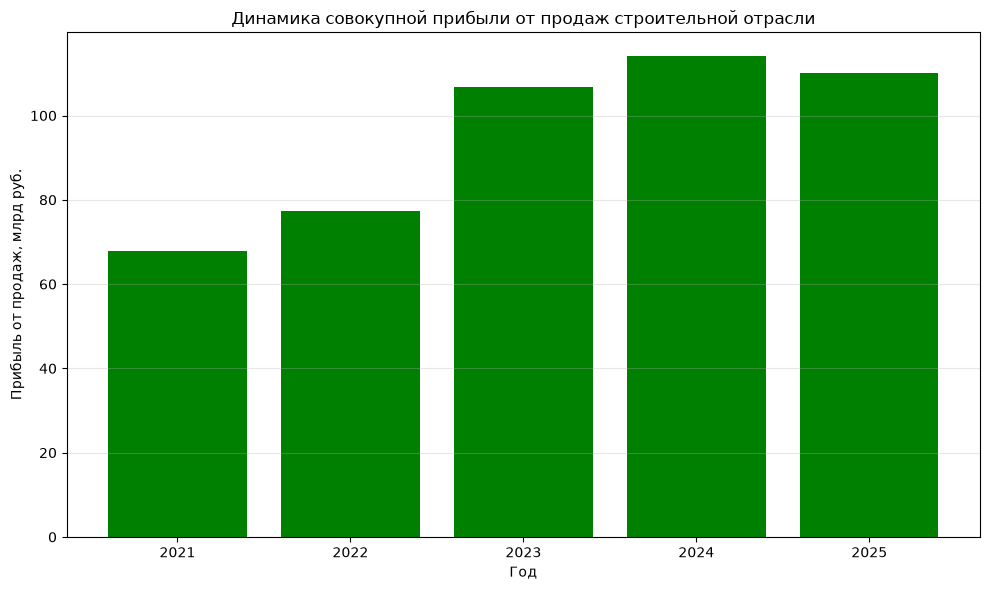

In [161]:
industry_operating_profit = plot_operating_profit(
    df_operating_profit_clear
)

In [162]:
df_margins = df_inn_data[
    [
        "ИНН",
        "Год",
        "Выручка",
        "Валовая прибыль",
        "Прибыль от продаж",
        "Чистая прибыль"
    ]
].copy()

df_margins = df_margins.dropna(
    subset=[
        "Год",
        "Выручка",
        "Валовая прибыль",
        "Прибыль от продаж",
        "Чистая прибыль"
    ]
)

valid_inns = (
    df_margins
    .groupby("ИНН")["Год"]
    .nunique()
)

valid_inns = valid_inns[valid_inns == 5].index

df_margins_clear = df_margins[
    df_margins["ИНН"].isin(valid_inns)
].copy()

In [163]:

def plot_industry_margins(df):

    industry = (
        df.groupby("Год", as_index=False)
          .agg({
              "Выручка": "sum",
              "Валовая прибыль": "sum",
              "Прибыль от продаж": "sum",
              "Чистая прибыль": "sum"
          })
          .sort_values("Год")
    )

    # Валовая маржа
    industry["Валовая маржа, %"] = (
        industry["Валовая прибыль"]
        / industry["Выручка"]
        * 100
    )

    # Операционная маржа
    industry["Операционная маржа, %"] = (
        industry["Прибыль от продаж"]
        / industry["Выручка"]
        * 100
    )

    # Чистая маржа
    industry["Чистая маржа, %"] = (
        industry["Чистая прибыль"]
        / industry["Выручка"]
        * 100
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.plot(
        industry["Год"],
        industry["Валовая маржа, %"],
        marker="o",
        linewidth=2,
        label="Валовая маржа"
    )

    ax.plot(
        industry["Год"],
        industry["Операционная маржа, %"],
        marker="o",
        linewidth=2,
        label="Операционная маржа"
    )

    ax.plot(
        industry["Год"],
        industry["Чистая маржа, %"],
        marker="o",
        linewidth=2,
        label="Чистая маржа"
    )

    ax.set_xlabel("Год")
    ax.set_ylabel("Маржа, %")

    ax.set_title(
        "Динамика маржинальности строительной отрасли"
    )

    ax.set_xticks(industry["Год"])

    ax.axhline(
        0,
        linewidth=1,
        linestyle="--",
        alpha=0.5
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

    return industry

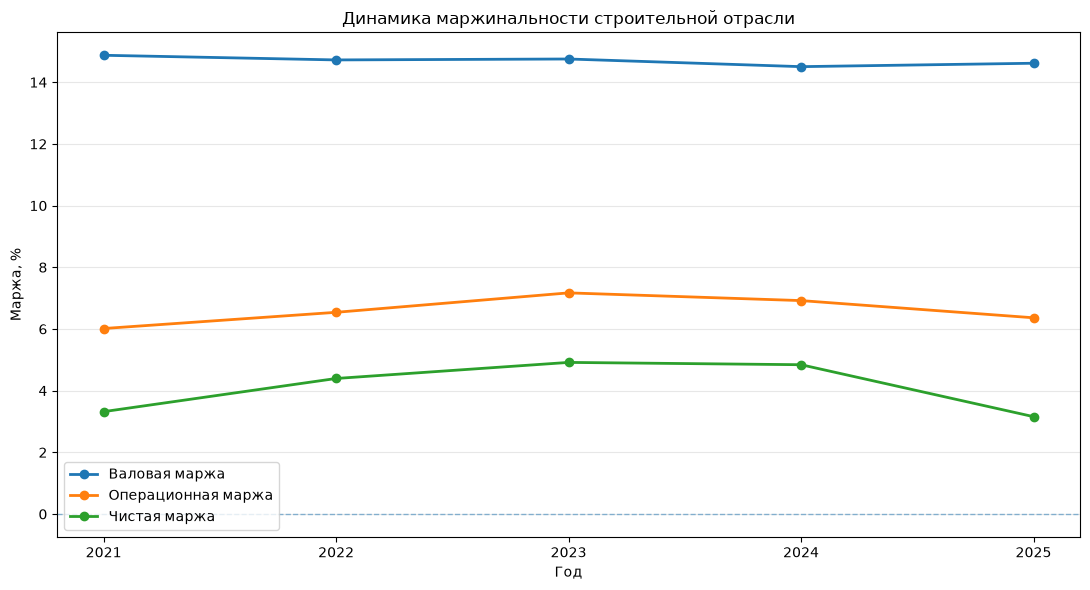

In [164]:
industry_margins = plot_industry_margins(
    df_margins_clear
)

In [165]:
def plot_growth_distribution(df, start_year, end_year, 
                             metric='Чистая прибыль', 
                             bins=30,
                             lower_percentile=0.01,
                             upper_percentile=0.99):

    data = df[['ИНН', 'Год', metric]].copy()
    data = data[data['Год'].isin([start_year, end_year])]
    data = data.dropna(subset=['Год', metric])
    
    inn_with_both = data.groupby('ИНН')['Год'].nunique()
    inn_with_both = inn_with_both[inn_with_both == 2].index
    data = data[data['ИНН'].isin(inn_with_both)]
    
    pivot = data.pivot(index='ИНН', columns='Год', values=metric)
    
    start_vals = pivot[start_year]
    end_vals = pivot[end_year]
    
    denom = start_vals.abs()
    denom = denom.replace(0, 1) 
    
    growth = (end_vals - start_vals) / denom * 100
    growth.name = f'Рост {metric}, %'
    
    lower = growth.quantile(lower_percentile)
    upper = growth.quantile(upper_percentile)
    growth_clean = growth[(growth >= lower) & (growth <= upper)]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(growth_clean, bins=bins, edgecolor='black', alpha=0.8)
    ax.axvline(0, linestyle='--', linewidth=1.5, color='black')
    ax.axvline(growth_clean.mean(), color='red', linestyle='-', 
               linewidth=1.5, label=f'Среднее = {growth_clean.mean():.1f}%')
    ax.axvline(growth_clean.median(), color='darkkhaki', linestyle='-', 
               linewidth=1.5, label=f'Медиана = {growth_clean.median():.1f}%')
    
    ax.set_xlabel(f'Изменение {metric.lower()} с {start_year} по {end_year}, %')
    ax.set_ylabel('Количество компаний')
    ax.set_title(f'Распределение компаний по росту {metric.lower()}\n'
                 f'(n = {len(growth_clean)}), выборка компании попавших после очистки от выбросов')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return growth

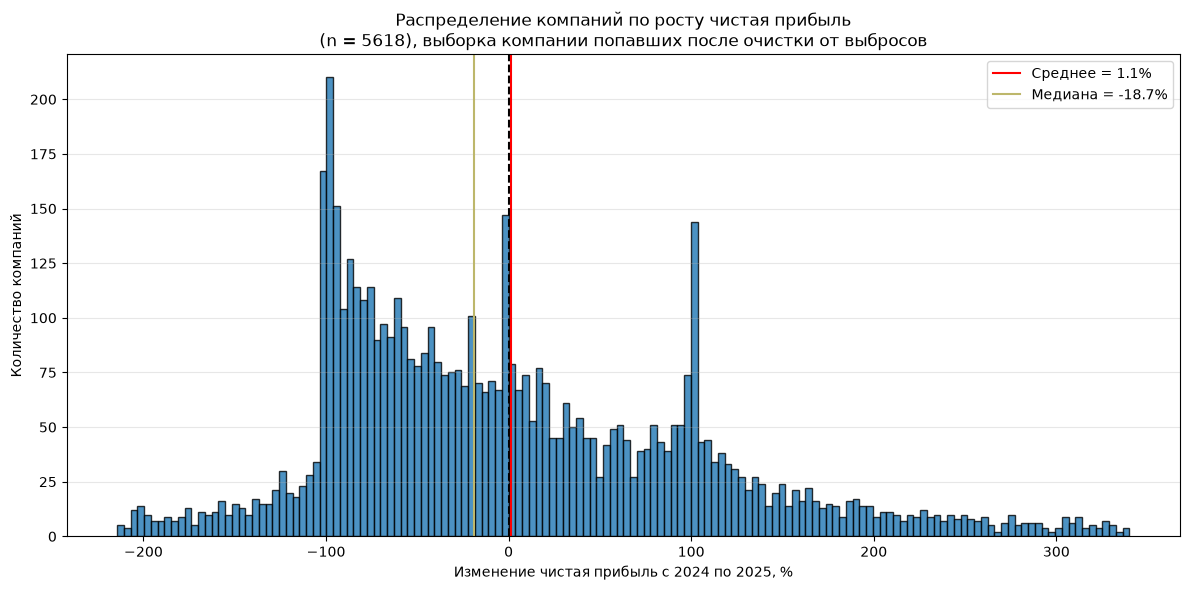

In [166]:
growth_series = plot_growth_distribution(
    df=df_inn_data,
    start_year=2024,
    end_year=2025,
    metric='Чистая прибыль',
    bins=150,
    lower_percentile=0.1,  
    upper_percentile=0.9
)


In [167]:
def plot_profitable_share(df, years, metric='Чистая прибыль'):

  
    data = df[['ИНН', 'Год', metric]].copy()
    data = data[data['Год'].isin(years)]
    data = data.dropna(subset=['Год', metric])
    
    
    inn_counts = data.groupby('ИНН')['Год'].nunique()
    valid_inns = inn_counts[inn_counts == len(years)].index
    data = data[data['ИНН'].isin(valid_inns)]
    
  
    data['Прибыльная'] = data[metric] > 0
    
   
    industry = (
        data.groupby('Год', as_index=False)
            .agg(
                Всего_компаний=('ИНН', 'nunique'),
                Прибыльных_компаний=('Прибыльная', 'sum')
            )
            .sort_values('Год')
    )
    industry['Доля прибыльных, %'] = (industry['Прибыльных_компаний'] / industry['Всего_компаний']) * 100
    
   
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(industry['Год'].astype(int), industry['Доля прибыльных, %'], color='cyan')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_xlabel('Год')
    ax.set_ylabel('Доля прибыльных компаний, %')
    ax.set_title(f'Доля прибыльных компаний ({metric})')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return industry

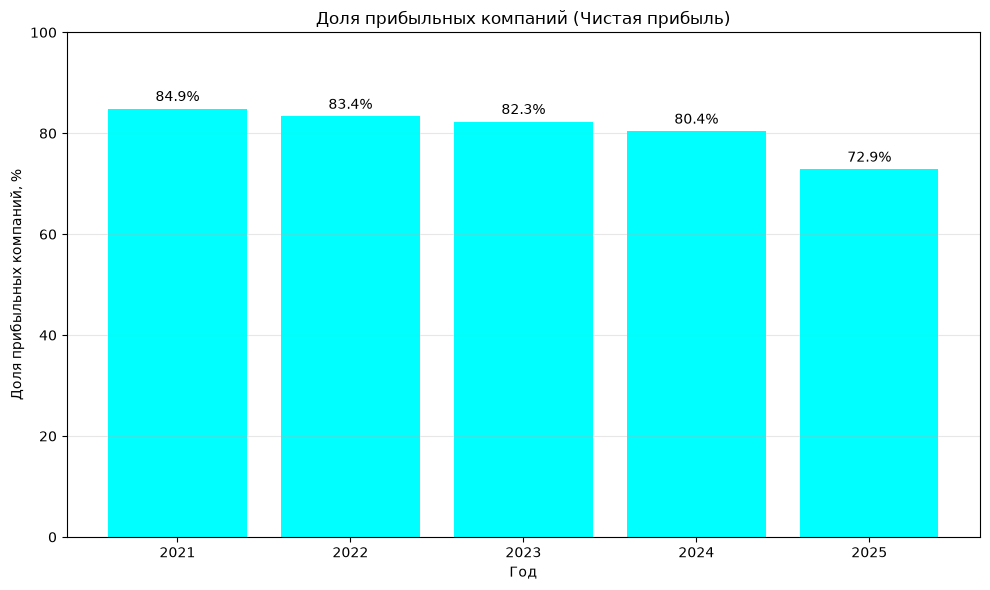

In [168]:
df_share = plot_profitable_share(
    df=df_inn_data,
    years=[2021, 2022, 2023, 2024, 2025],
    metric='Чистая прибыль'
)

In [169]:

def plot_icr(df):

    data = df[
        ["Год", "Прибыль от продаж", "Проценты к уплате"]
    ].copy()

    data = data.dropna(
        subset=["Год", "Прибыль от продаж", "Проценты к уплате"]
    )

    # Проценты берём по модулю
    data["Проценты к уплате"] = (
        data["Проценты к уплате"].abs()
    )

    # Агрегируем по отрасли
    industry = (
        data.groupby("Год", as_index=False)
            .agg({
                "Прибыль от продаж": "sum",
                "Проценты к уплате": "sum"
            })
            .sort_values("Год")
    )

    # Коэффициент покрытия процентов
    industry["ICR"] = (
        industry["Прибыль от продаж"]
        / industry["Проценты к уплате"]
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(
        industry["Год"].astype(int),
        industry["ICR"],
        color="green"
    )

    # Значения над столбиками
    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3
    )

    # Ориентир
    ax.axhline(
        1.5,
        color="red",
        linestyle="--",
        label="Уровень 1.5"
    )

    ax.set_xlabel("Год")
    ax.set_ylabel("ICR")

    ax.set_title(
        "Коэффициент покрытия процентов строительной отрасли"
    )

    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return industry

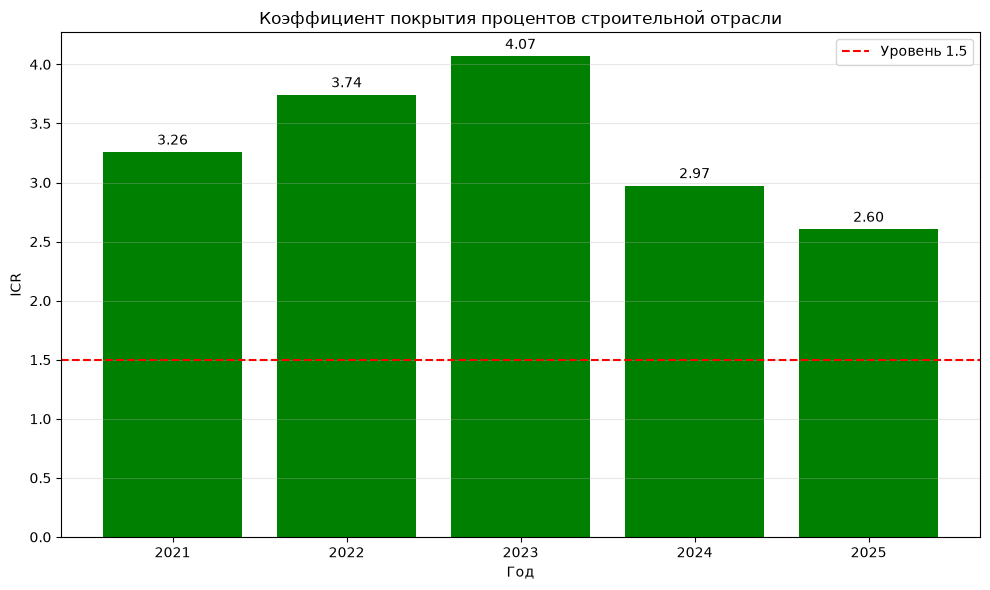

In [170]:
icr_data = plot_icr(df_inn_data)

In [171]:
def plot_current_ratio(df):

    data = df[
        ["ИНН", "Год", "Оборотные активы", "Краткосрочные обязательства"]
    ].copy()

    data = data.dropna(
        subset=["Год", "Оборотные активы", "Краткосрочные обязательства"]
    )

    valid_inns = (
        data.groupby("ИНН")["Год"]
            .nunique()
    )

    valid_inns = valid_inns[valid_inns == 5].index

    data = data[
        data["ИНН"].isin(valid_inns)
    ].copy()

    industry = (
        data.groupby("Год", as_index=False)
            .agg({
                "Оборотные активы": "sum",
                "Краткосрочные обязательства": "sum"
            })
            .sort_values("Год")
    )

    industry["Current Ratio"] = (
        industry["Оборотные активы"]
        / industry["Краткосрочные обязательства"]
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(
        industry["Год"].astype(int),
        industry["Current Ratio"],
        color="#4C78A8"
    )

    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3
    )

    ax.axhline(
        1,
        color="red",
        linestyle="--",
        label="Уровень 1.0"
    )

    ax.set_xlabel("Год")
    ax.set_ylabel("Current Ratio")
    ax.set_ylim(0.5, 2)
    ax.set_title(
        "Коэффициент текущей ликвидности строительной отрасли"
    )

    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return industry

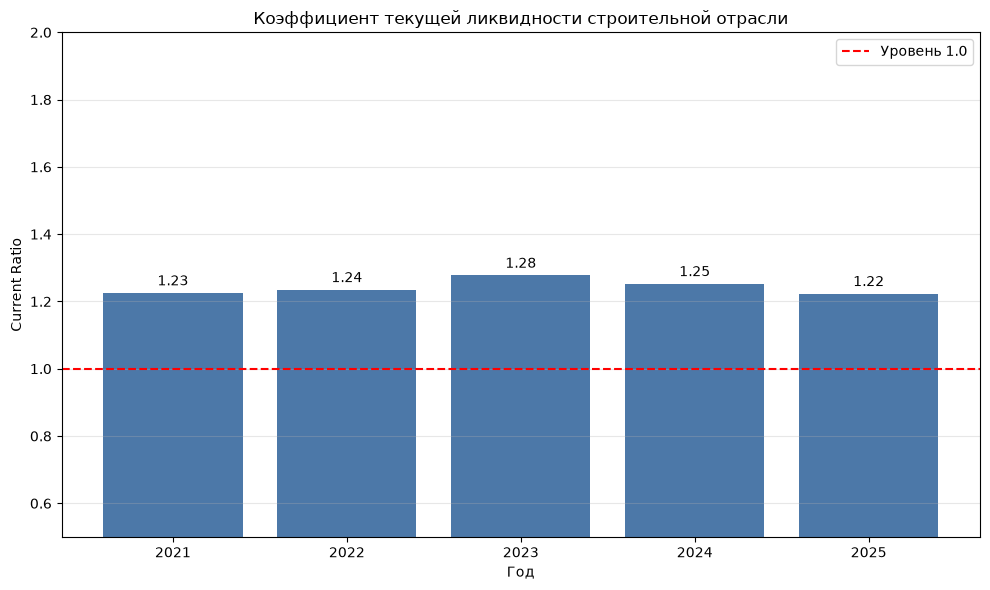

In [172]:
current_ratio_data = plot_current_ratio(df_inn_data)

In [173]:
def plot_debt_to_equity(df):

    data = df[
        [
            "ИНН",
            "Год",
            "Капитал и резервы",
            "Долгосрочные обязательства",
            "Краткосрочные обязательства"
        ]
    ].copy()

    data = data.dropna(
        subset=[
            "Год",
            "Капитал и резервы",
            "Долгосрочные обязательства",
            "Краткосрочные обязательства"
        ]
    )

    valid_inns = (
        data.groupby("ИНН")["Год"]
            .nunique()
    )

    valid_inns = valid_inns[valid_inns == 5].index

    data = data[
        data["ИНН"].isin(valid_inns)
    ].copy()

    industry = (
        data.groupby("Год", as_index=False)
            .agg({
                "Капитал и резервы": "sum",
                "Долгосрочные обязательства": "sum",
                "Краткосрочные обязательства": "sum"
            })
            .sort_values("Год")
    )

    industry["Обязательства"] = (
        industry["Долгосрочные обязательства"]
        + industry["Краткосрочные обязательства"]
    )

    industry["Debt-to-Equity"] = (
        industry["Обязательства"]
        / industry["Капитал и резервы"]
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(
        industry["Год"].astype(int),
        industry["Debt-to-Equity"],
        color="#4C78A8"
    )

    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3
    )

    ax.axhline(
        1,
        color="red",
        linestyle="--",
        label="D/E = 1"
    )

    ax.set_xlabel("Год")
    ax.set_ylabel("Debt-to-Equity")
    ax.set_ylim(0.1, 10)
    
    ax.set_title(
        "Долговая нагрузка строительной отрасли"
    )

    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return industry

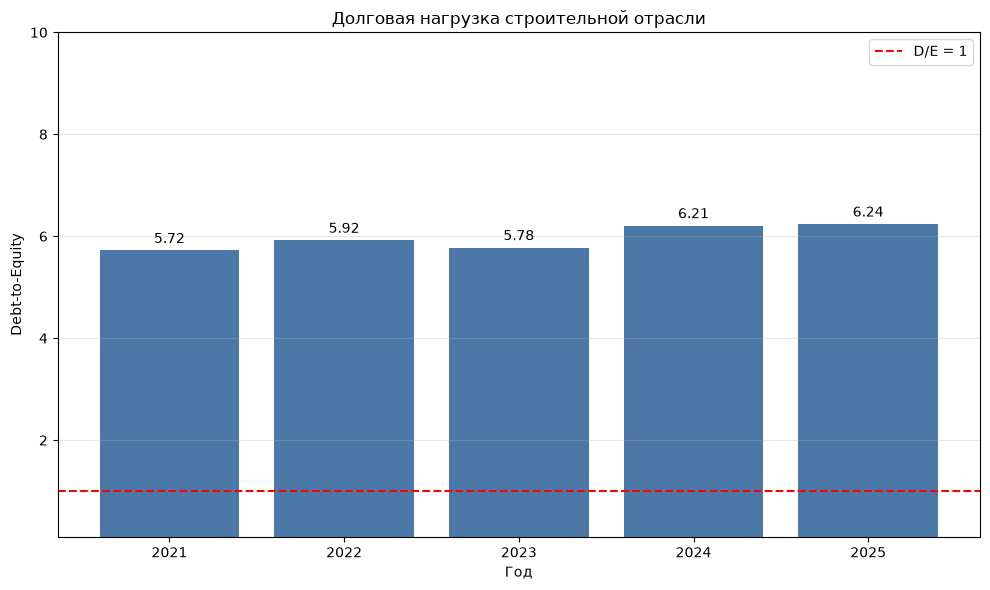

In [174]:
debt_equity_data = plot_debt_to_equity(df_inn_data)

In [175]:
def plot_cost_structure(df):

    data = df[
        [
            "ИНН",
            "Год",
            "Выручка",
            "Себестоимость",
            "Управленческие расходы",
            "Проценты к уплате"
        ]
    ].copy()

    data = data.dropna(
        subset=[
            "Год",
            "Выручка",
            "Себестоимость",
            "Управленческие расходы",
            "Проценты к уплате"
        ]
    )

    valid_inns = (
        data.groupby("ИНН")["Год"]
            .nunique()
    )

    valid_inns = valid_inns[valid_inns == 5].index

    data = data[
        data["ИНН"].isin(valid_inns)
    ].copy()

    data["Себестоимость"] = data["Себестоимость"].abs()
    data["Управленческие расходы"] = data["Управленческие расходы"].abs()
    data["Проценты к уплате"] = data["Проценты к уплате"].abs()

    industry = (
        data.groupby("Год", as_index=False)
            .agg({
                "Выручка": "sum",
                "Себестоимость": "sum",
                "Управленческие расходы": "sum",
                "Проценты к уплате": "sum"
            })
            .sort_values("Год")
    )

    industry["Себестоимость, %"] = (
        industry["Себестоимость"]
        / industry["Выручка"]
        * 100
    )

    industry["Управленческие расходы, %"] = (
        industry["Управленческие расходы"]
        / industry["Выручка"]
        * 100
    )

    industry["Проценты к уплате, %"] = (
        industry["Проценты к уплате"]
        / industry["Выручка"]
        * 100
    )

    # График
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.plot(
        industry["Год"],
        industry["Себестоимость, %"],
        marker="o",
        linewidth=2,
        label="Себестоимость"
    )

    ax.plot(
        industry["Год"],
        industry["Управленческие расходы, %"],
        marker="o",
        linewidth=2,
        label="Управленческие расходы"
    )

    ax.plot(
        industry["Год"],
        industry["Проценты к уплате, %"],
        marker="o",
        linewidth=2,
        label="Проценты к уплате"
    )

    ax.set_xlabel("Год")
    ax.set_ylabel("Доля от выручки, %")

    ax.set_title(
        "Динамика основных расходов строительной отрасли"
    )

    ax.set_xticks(industry["Год"])

    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return industry

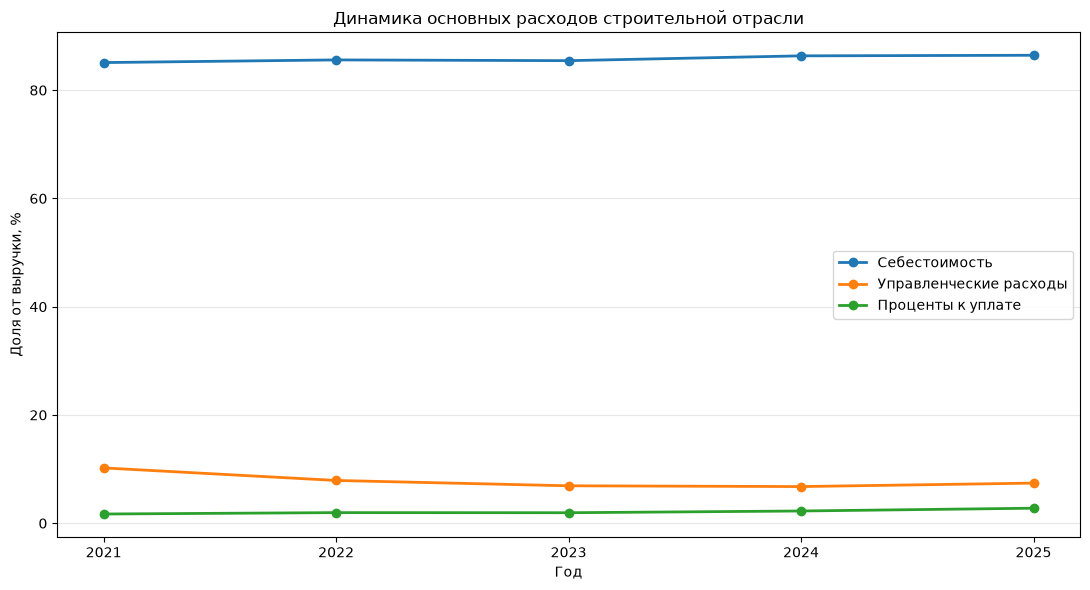

In [176]:
cost_structure_data = plot_cost_structure(df_inn_data)

In [177]:
def plot_capital_structure(df):

    data = df[
        [
            "ИНН",
            "Год",
            "Капитал и резервы",
            "Долгосрочные обязательства",
            "Краткосрочные обязательства"
        ]
    ].copy()

    data = data.dropna(
        subset=[
            "Год",
            "Капитал и резервы",
            "Долгосрочные обязательства",
            "Краткосрочные обязательства"
        ]
    )

    valid_inns = (
        data.groupby("ИНН")["Год"]
            .nunique()
    )

    valid_inns = valid_inns[valid_inns == 5].index

    data = data[
        data["ИНН"].isin(valid_inns)
    ].copy()

    industry = (
        data.groupby("Год", as_index=False)
            .agg({
                "Капитал и резервы": "sum",
                "Долгосрочные обязательства": "sum",
                "Краткосрочные обязательства": "sum"
            })
            .sort_values("Год")
    )

    industry["Всего"] = (
        industry["Капитал и резервы"]
        + industry["Долгосрочные обязательства"]
        + industry["Краткосрочные обязательства"]
    )

    industry["Капитал, %"] = (
        industry["Капитал и резервы"]
        / industry["Всего"]
        * 100
    )

    industry["Долгосрочные обязательства, %"] = (
        industry["Долгосрочные обязательства"]
        / industry["Всего"]
        * 100
    )

    industry["Краткосрочные обязательства, %"] = (
        industry["Краткосрочные обязательства"]
        / industry["Всего"]
        * 100
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(
        industry["Год"],
        industry["Капитал, %"],
        label="Капитал и резервы"
    )

    ax.bar(
        industry["Год"],
        industry["Долгосрочные обязательства, %"],
        bottom=industry["Капитал, %"],
        label="Долгосрочные обязательства"
    )

    ax.bar(
        industry["Год"],
        industry["Краткосрочные обязательства, %"],
        bottom=(
            industry["Капитал, %"]
            + industry["Долгосрочные обязательства, %"]
        ),
        label="Краткосрочные обязательства"
    )

    ax.set_xlabel("Год")
    ax.set_ylabel("Доля, %")
    ax.set_ylim(0, 150)

    ax.set_title(
        "Структура источников финансирования строительной отрасли"
    )

    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    return industry

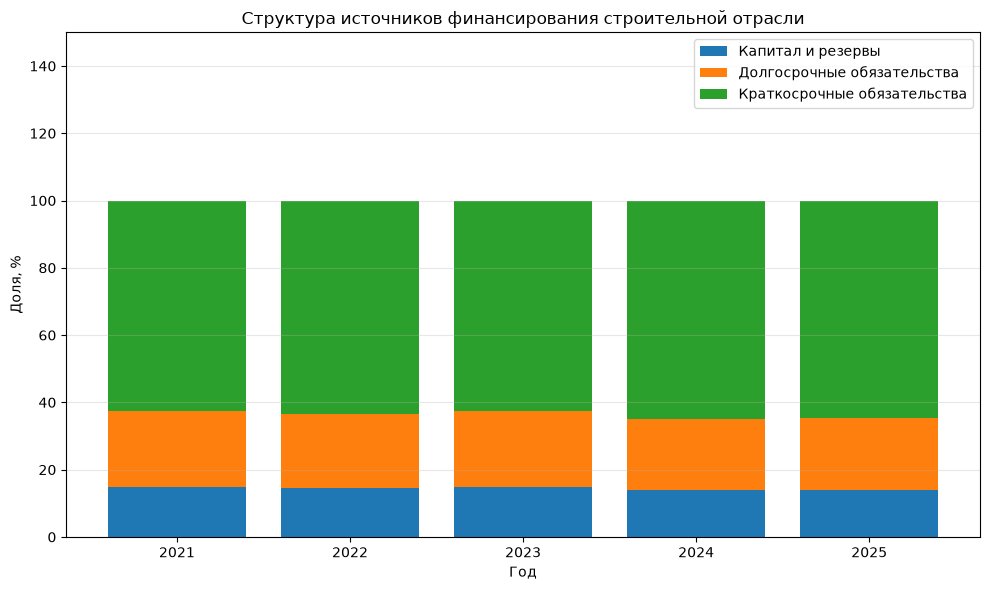

In [178]:
capital_structure_data = plot_capital_structure(df_inn_data)

In [179]:
# общий вывод исходя из всех графиков: 
# учтем некоторый контекст, который касается ключевой ставки:
# К концу 2023 года ключевая ставка Банка России выросла до 16%, в 2024 году она дошла до 21% и оставалась на этом уровне до июня 2025 года;
# затем начался цикл снижения — до 20%, затем 18% и позднее 17%
#
# Одновременно массовая программа «Льготная ипотека» под 8% завершилась 1 июля 2024 года, хотя более адресная «Семейная ипотека» сохранилась.
# начиная с 2021 года темпы роста выручки снижались, хотя и не падали ниже нуля, однако если посмотреть на график прибыли, то начиная с 2023 года 
# в % содержании она падала, причем на значительную величину: сначала снизился прирост с 23 года на 20%, а потом и вовсе прибыль упала на 40%
# относительно 24 года
# рынок в денежном выражении продолжает расти, но каждый рубль выручки начинает приносить меньше конечной прибыли
# В операционной же прибыли дела обстоят несколько более лучшим образом, я взял метрику "прибыль от продаж". На ФБО она и считается как EBIT
# Здесь видим в целом рост и небольшое снижение в 2025 году. 

# но стоит указать, что процент прибыльных компании с каждым годом снижается. 
# В условиях высокой себестоимости и высокой ключевой ставки компаниям тяжелее
# из операционной прибыли получать чистую. Долговая нагрузка увеличивается с 23 года.
# То есть на каждый рубль собственного капитала приходится 6 заемных
# если посмотреть на график ICR (покрытие процентов) то начиная с 24 года идет резкое ухудшение. Запас прочности довольно сильно сократился за 2 года.

# Интересно посмотреть на график распределения компаний и их относительной прибыли. Медиана показывает -18% для строительной отрасли, 
# а среднее около нуляю.

# Касаемо коэффициента текущей ликвидности: компании балансируют на грани допустимого минимума.

# общий вывод: в 2021–2023 годах строительная отрасль демонстрировала расширение бизнеса и повышение прибыльности 
# 2023 год стал локальным максимумом большинства показателей финансовой эффективности.
# С 2024 года, на фоне ужесточения денежно-кредитной политики и изменения системы ипотечной поддержки,
# начинается ухудшение финансовых показателей. В 2025 году номинальная выручка ещё растёт, 
# однако чистая прибыль резко снижается, сокращается доля прибыльных компаний,
# падают ICR и ликвидность и растёт отношение обязательств к капиталу. 
# При этом стабильная валовая маржа показывает, 
# что основной источник давления находится не в резком росте прямой себестоимости, а 
# прежде всего в финансовой нагрузке и более сложных условиях привлечения и обслуживания капитала.


# касаемо про моржу, тут мне очень понравилась эта интерпетация от ИИ: 
# Валовая маржа (~14.5%): Стабильна.
# Это значит, что разница между ценой продажи квартир и их прямой себестоимостью (стройматериалы, работа рабочих) принципиально не изменилась. 
# Застройщики все еще продают жилье с хорошей базовой наценкой.
# Операционная маржа (падает с 7.2% до ~6.4%): Показывает прибыль после вычета коммерческих и управленческих расходов 
# (маркетинг, реклама для привлечения покупателей, офисы). 
# Падение говорит о том, что продавать квартиры в 2024–2025 гг. стало сложнее и дороже.Чистая маржа (резко падает с 4.9% до ~3.2%):
# Самый тревожный маркер. 
# Это чистая прибыль, которая остается у компаний после уплаты налогов и, главное, процентов по кредитам.

In [180]:

top_500 = (
    df_inn_data[
        (df_inn_data["Год"] == 2025)
        & (df_inn_data["Выручка"].notna())
    ]
    .sort_values("Выручка", ascending=False)
    .drop_duplicates(subset="ИНН")
    .head(500)
    .copy()
)

top_500_inns = top_500["ИНН"].tolist()

In [181]:
len(top_500_inns)



500

In [182]:
# import random

# all_addresses = []

# session = requests.Session()

# for inn in tqdm(top_500_inns):
#     try:
#         url_search = (
#             f"https://bo.nalog.gov.ru/"
#             f"advanced-search/organizations/search?query={inn}"
#         )

#         headers = {
#             "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
#             "Accept": "application/json, text/plain, */*",
#             "Referer": "https://bo.nalog.gov.ru/advanced-search"
#         }

#         resp = session.get(
#             url_search,
#             headers=headers,
#             timeout=15
#         )

#         if resp.status_code == 429:
#             print(f"\nTOO MANY REQUESTS на ИНН {inn}")
#             break

#         if resp.status_code != 200:
#             print(f"Ошибка поиска {inn}: {resp.status_code}")
#             time.sleep(random.uniform(0.3, 0.8))
#             continue

#         data = resp.json()

#         if not data.get("content"):
#             print(f"ИНН {inn} не найден")
#             time.sleep(random.uniform(0.3, 0.8))
#             continue

#         org_id = data["content"][0]["id"]

#         url_bfo = (
#             f"https://bo.nalog.gov.ru/"
#             f"nbo/organizations/{org_id}/bfo/"
#         )

#         resp_bfo = session.get(
#             url_bfo,
#             headers={"User-Agent": "Mozilla/5.0"},
#             timeout=15
#         )

#         if resp_bfo.status_code == 429:
#             print(f"\nBFO: TOO MANY REQUESTS на ИНН {inn}")
#             break

#         if resp_bfo.status_code != 200:
#             print(f"Ошибка BFO для {inn}: {resp_bfo.status_code}")
#             time.sleep(random.uniform(0.3, 0.8))
#             continue

#         bfo_data = resp_bfo.json()

#         if bfo_data:
#             address = (
#                 bfo_data[0]
#                 .get("organizationInfo", {})
#                 .get("address")
#             )

#             if address:
#                 all_addresses.append({
#                     "ИНН": inn,
#                     "Адрес": address
#                 })
#             else:
#                 print(f"Для ИНН {inn} адрес отсутствует")

#         time.sleep(random.uniform(0.3, 0.8))

#     except Exception as e:
#         print(f"Ошибка для ИНН {inn}: {e}")
#         time.sleep(random.uniform(0.3, 0.5))
#         continue

# df_adress_inn = pd.DataFrame(all_addresses)
# df_adress_inn.head()

!gdown  "https://drive.google.com/file/d/1-jLllUwZAMUwb3qFd-m00UsMLgwDmHgZ/view?usp=sharing" -O adress_inns.csv
df_adress_inn = pd.read_csv("adress_inns.csv")

Downloading...
From: https://drive.google.com/uc?id=1-jLllUwZAMUwb3qFd-m00UsMLgwDmHgZ
To: C:\Users\Honor\PycharmProjects\Something file\adress_inns.csv

  0%|          | 0.00/78.9k [00:00<?, ?B/s]
100%|##########| 78.9k/78.9k [00:00<00:00, 852kB/s]


In [183]:
df_adress_inn.head(6)

,ИНН,Адрес
0,5401304044,"630008, Новосибирская обл, г.о. город Новосиби..."
1,7702681515,"111250, Москва г, вн.тер.г. муниципальный окру..."
2,5257145631,"603093, Нижегородская область, г. Нижний Новго..."
3,4004021545,"249832, Калужская область, р-н Дзержинский, г...."
4,7705989107,"129515, Город Москва, ул. Академика Королева, ..."
5,7730032150,"111024, Город Москва, вн.тер.г. муниципальный ..."


In [184]:
df_inn_data.head()

,ИНН,Год,Выручка,Себестоимость,Валовая прибыль,Управленческие расходы,Прибыль от продаж,Проценты к уплате,Чистая прибыль,Оборотные активы,Капитал и резервы,Долгосрочные обязательства,Краткосрочные обязательства,Налог на прибыль
0,5038038838,2025,140064.0,103274.0,36790.0,36435.0,355.0,11869.0,-520.0,313708.0,630589.0,3710.0,258798.0,-63.0
1,5038038838,2024,112540.0,95619.0,16921.0,25710.0,-8789.0,1521.0,-20129.0,420322.0,611107.0,NaN,157656.0,-191.0
2,5038038838,2023,108966.0,90500.0,18466.0,25408.0,-8093.0,3334.0,-20913.0,469298.0,606621.0,NaN,198290.0,-248.0
3,5038038838,2022,118633.0,83747.0,34886.0,28364.0,2396.0,141.0,19518.0,487345.0,627535.0,0.0,258088.0,-336.0
4,5038038838,2021,184044.0,150023.0,34021.0,37142.0,-5813.0,5601.0,3080.0,532675.0,608017.0,0.0,351596.0,-320.0


In [185]:
df_inn_data_2025 = df_inn_data[df_inn_data["Год"] == 2025].copy()

In [186]:
df_inn_data_2025 = df_inn_data_2025[["ИНН", "Выручка"]].copy()

In [187]:
df_2025_with_address = df_adress_inn.merge(df_inn_data_2025, on="ИНН", how="left")

In [188]:
df_2025_with_address.head()

,ИНН,Адрес,Выручка
0,5401304044,"630008, Новосибирская обл, г.о. город Новосиби...",18261572.0
1,7702681515,"111250, Москва г, вн.тер.г. муниципальный окру...",14902058.0
2,5257145631,"603093, Нижегородская область, г. Нижний Новго...",12406715.0
3,4004021545,"249832, Калужская область, р-н Дзержинский, г....",11677648.0
4,7705989107,"129515, Город Москва, ул. Академика Королева, ...",10800142.0


In [189]:
df_2025_with_address = df_2025_with_address.sort_values("Выручка", ascending=False)

In [190]:
df_2025_with_address

,ИНН,Адрес,Выручка
0,5401304044,"630008, Новосибирская обл, г.о. город Новосиби...",18261572.0
1,7702681515,"111250, Москва г, вн.тер.г. муниципальный окру...",14902058.0
2,5257145631,"603093, Нижегородская область, г. Нижний Новго...",12406715.0
3,4004021545,"249832, Калужская область, р-н Дзержинский, г....",11677648.0
4,7705989107,"129515, Город Москва, ул. Академика Королева, ...",10800142.0
...,...,...,...
495,7802199601,"194214, Санкт-Петербург г, пр-кт Костромской, ...",1191586.0
496,1840068380,"426072, Удмуртская респ, г Ижевск, ул Молодежн...",1191028.0
497,6658070216,"620000, Свердловская обл, г.о. город Екатеринб...",1179192.0
498,4703156697,"188689, Ленинградская обл, р-н Всеволожский, г...",1179174.0


In [191]:
from geopy.geocoders import ArcGIS
from geopy.extra.rate_limiter import RateLimiter
from tqdm.notebook import tqdm


!gdown  "https://drive.google.com/file/d/194gfjZXul2kHXky1jpE3PLnVInFq9sMv/view?usp=sharing" -O df_2025_with_address.csv
df_2025_with_address = pd.read_csv("df_2025_with_address.csv")

# tqdm.pandas()
# geolocator = ArcGIS(timeout=15)

# geocode = RateLimiter(
#     geolocator.geocode,
#     min_delay_seconds=0.3
# )

Downloading...
From: https://drive.google.com/uc?id=194gfjZXul2kHXky1jpE3PLnVInFq9sMv
To: C:\Users\Honor\PycharmProjects\Something file\df_2025_with_address.csv

  0%|          | 0.00/146k [00:00<?, ?B/s]
100%|##########| 146k/146k [00:00<00:00, 1.20MB/s]
100%|##########| 146k/146k [00:00<00:00, 1.20MB/s]


In [192]:
# df_2025_with_address["location"] = (
#     df_2025_with_address["Адрес"]
#     .progress_apply(geocode)
# )

In [193]:
print(
    "Найдено:",
    df_2025_with_address["location"].notna().sum(),
    "из",
    len(df_2025_with_address)
)

Найдено: 500 из 500


In [194]:

df_2025_with_address

,ИНН,Адрес,Выручка,location,latitude,longitude
0,5401304044,"630008, Новосибирская обл, г.о. город Новосиби...",18261572.0,"Кирова улица, 113, Новосибирск, Новосибирская ...",55.013155,82.954476
1,7702681515,"111250, Москва г, вн.тер.г. муниципальный окру...",14902058.0,"Крузенштерна улица, Москва, 111250",55.752394,37.701597
2,5257145631,"603093, Нижегородская область, г. Нижний Новго...",12406715.0,"Яблоневая улица, 28, Нижний Новгород, Нижегоро...",56.312937,44.056305
3,4004021545,"249832, Калужская область, р-н Дзержинский, г....",11677648.0,"Комсомольская улица, 11А, Кондрово, Дзержински...",54.805996,35.926234
4,7705989107,"129515, Город Москва, ул. Академика Королева, ...",10800142.0,"Академика Королева улица, 13, Москва, 129515",55.820145,37.619544
...,...,...,...,...,...,...
495,7802199601,"194214, Санкт-Петербург г, пр-кт Костромской, ...",1191586.0,"Костромской проспект, 62, Санкт-Петербург, 194214",60.026373,30.312543
496,1840068380,"426072, Удмуртская респ, г Ижевск, ул Молодежн...",1191028.0,"Молодежная улица, 46, Ижевск, Удмуртская респу...",56.851746,53.288499
497,6658070216,"620000, Свердловская обл, г.о. город Екатеринб...",1179192.0,"Ленина проспект, 5, Екатеринбург, Свердловская...",56.836652,60.582206
498,4703156697,"188689, Ленинградская обл, р-н Всеволожский, г...",1179174.0,"Новая улица, 14А, Янино-1, Всеволожский район,...",59.948643,30.567271


In [195]:
# df_2025_with_address["latitude"] = (
#     df_2025_with_address["location"]
#     .apply(lambda x: x.latitude)
# )

# df_2025_with_address["longitude"] = (
#     df_2025_with_address["location"]
#     .apply(lambda x: x.longitude)
# )

In [196]:
df_2025_with_address[
    ["ИНН", "Адрес", "Выручка", "latitude", "longitude"]
].head()

,ИНН,Адрес,Выручка,latitude,longitude
0,5401304044,"630008, Новосибирская обл, г.о. город Новосиби...",18261572.0,55.013155,82.954476
1,7702681515,"111250, Москва г, вн.тер.г. муниципальный окру...",14902058.0,55.752394,37.701597
2,5257145631,"603093, Нижегородская область, г. Нижний Новго...",12406715.0,56.312937,44.056305
3,4004021545,"249832, Калужская область, р-н Дзержинский, г....",11677648.0,54.805996,35.926234
4,7705989107,"129515, Город Москва, ул. Академика Королева, ...",10800142.0,55.820145,37.619544


In [197]:
geo_top500 = gpd.GeoDataFrame(
    df_2025_with_address.copy(),
    geometry=gpd.points_from_xy(
        df_2025_with_address["longitude"],
        df_2025_with_address["latitude"]
    ),
    crs="EPSG:4326"
)

In [198]:
geo_top500.head()

,ИНН,Адрес,Выручка,location,latitude,longitude,geometry
0,5401304044,"630008, Новосибирская обл, г.о. город Новосиби...",18261572.0,"Кирова улица, 113, Новосибирск, Новосибирская ...",55.013155,82.954476,POINT (82.95448 55.01316)
1,7702681515,"111250, Москва г, вн.тер.г. муниципальный окру...",14902058.0,"Крузенштерна улица, Москва, 111250",55.752394,37.701597,POINT (37.7016 55.75239)
2,5257145631,"603093, Нижегородская область, г. Нижний Новго...",12406715.0,"Яблоневая улица, 28, Нижний Новгород, Нижегоро...",56.312937,44.056305,POINT (44.0563 56.31294)
3,4004021545,"249832, Калужская область, р-н Дзержинский, г....",11677648.0,"Комсомольская улица, 11А, Кондрово, Дзержински...",54.805996,35.926234,POINT (35.92623 54.806)
4,7705989107,"129515, Город Москва, ул. Академика Королева, ...",10800142.0,"Академика Королева улица, 13, Москва, 129515",55.820145,37.619544,POINT (37.61954 55.82014)


In [199]:

import plotly.express as px
import plotly.io as pio


pio.renderers.default = "browser"

fig = px.scatter_map(
    geo_top500,
    lat="latitude",
    lon="longitude",
    hover_name="ИНН",
    hover_data={
        "Адрес": True,
        "Выручка": True,
        "latitude": False,
        "longitude": False
    },
    zoom=2,
    height=700
)

fig.update_layout(
    map_style="open-street-map",
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    title="TOP-500 строительных компаний России по выручке, 2025"
)

fig.show()
